# Assignment 9 — The Loss Harness (nanoGPT / GPT-2)

Make the next-token training loss **correct and observable**, then add a second head.
Architecture: Andrej Karpathy's nanoGPT / GPT-2. Data: **FineWeb** (`HuggingFaceFW/fineweb`, `sample-10BT`, streamed).

> **The one warning.** A target shift in the *wrong* direction can still produce a beautiful loss
> curve. **Print the strings.** Most serious training bugs live in the few lines between the model
> output and the scalar loss, and they do not raise an exception. Part 3 demonstrates exactly this.

**Parts**
- **Part 1** — the harness: shapes, string-verified shift, padding mask, document packing, perplexity, tied-vs-untied params, chunked-CE peak memory.
- **Part 2** — a second head predicting token `t+2`; report both losses and their sum, and what happens over training.
- **Part 3** — the off-by-one trap: a wrong shift that *looks* like it is learning, caught by printing strings.


## Setup
Install deps (Colab needs this; on a local Mac venv you may already have them).

In [1]:
%pip install -q tiktoken datasets matplotlib torch


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import math, time, torch, torch.nn as nn, torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt

torch.manual_seed(1337)

# Device: Apple Silicon (mps) -> CUDA -> CPU
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print("device:", device)

enc = tiktoken.get_encoding("gpt2")   # GPT-2 BPE tokenizer
VOCAB = enc.n_vocab
print("vocab size:", VOCAB)           # 50257

device: mps
vocab size: 50257


## Data — FineWeb (streamed)

We stream a handful of documents from FineWeb. Streaming means **no multi-GB download** — we pull
just enough text to (a) show real string shifts and (b) train the two heads for a couple of minutes.
A tiny fallback keeps the notebook runnable if the Hub is unreachable.

In [3]:
def load_fineweb_text(target_tokens=80_000):
    docs, buf = [], []
    try:
        from datasets import load_dataset
        ds = load_dataset("HuggingFaceFW/fineweb", name="sample-10BT",
                          split="train", streaming=True)
        for d in ds:
            t = d["text"].strip()
            if not t:
                continue
            docs.append(t)
            buf += enc.encode(t)
            if len(buf) >= target_tokens:
                break
        print(f"FineWeb: {len(docs)} docs, {len(buf)} tokens")
    except Exception as e:
        print("FineWeb unavailable, using fallback text. Reason:", repr(e))
        fallback = ("Machine learning models are trained by minimizing a loss function. "
                    "The cross entropy loss compares predicted token distributions with the "
                    "actual next tokens in the sequence. ") * 400
        docs = [fallback]
        buf = enc.encode(fallback)[:target_tokens]
    return docs, torch.tensor(buf[:target_tokens], dtype=torch.long)

fineweb_docs, fineweb_tokens = load_fineweb_text()
print("first doc preview:", repr(fineweb_docs[0][:160]))

Resolving data files:   0%|          | 0/27468 [00:00<?, ?it/s]

FineWeb: 116 docs, 80022 tokens
first doc preview: "|Viewing Single Post From: Spoilers for the Week of February 11th|\n|Lil||Feb 1 2013, 09:58 AM|\nDon't care about Chloe/Taniel/Jen-Jen. Don't care about Sami, rea"


## Model — nanoGPT / GPT-2

Standard nanoGPT block (pre-LN, causal self-attention via `scaled_dot_product_attention`, GELU MLP).
Two knobs matter for this assignment:

- `tied` — share the token-embedding matrix with the output head (GPT-2 does this).
- `two_heads` — add a second output head for Part 2.

**Init is not optional.** With PyTorch's default `nn.Embedding`/`nn.Linear` init (std ≈ 1), the tied
logits blow up and an *untrained* model reports loss ≈ 85 instead of ln(V) ≈ 10.82. nanoGPT's
std=0.02 init is what makes untrained perplexity land near the vocab size (verified in Part 1.5).

In [4]:
class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.n_embd % cfg.n_head == 0
        self.c_attn = nn.Linear(cfg.n_embd, 3 * cfg.n_embd)
        self.c_proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.n_head, self.n_embd = cfg.n_head, cfg.n_embd
    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        hs = C // self.n_head
        q = q.view(B, T, self.n_head, hs).transpose(1, 2)
        k = k.view(B, T, self.n_head, hs).transpose(1, 2)
        v = v.view(B, T, self.n_head, hs).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)  # causal mask
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.c_fc   = nn.Linear(cfg.n_embd, 4 * cfg.n_embd)
        self.gelu   = nn.GELU()
        self.c_proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd)
    def forward(self, x):
        return self.c_proj(self.gelu(self.c_fc(x)))

class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln_1 = nn.LayerNorm(cfg.n_embd); self.attn = CausalSelfAttention(cfg)
        self.ln_2 = nn.LayerNorm(cfg.n_embd); self.mlp  = MLP(cfg)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class Config:
    def __init__(self, vocab, block=64, n_layer=4, n_head=4, n_embd=128,
                 tied=True, two_heads=False):
        self.vocab_size = vocab; self.block_size = block
        self.n_layer = n_layer; self.n_head = n_head; self.n_embd = n_embd
        self.tied = tied; self.two_heads = two_heads

class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.n_embd)   # token embedding
        self.wpe = nn.Embedding(cfg.block_size, cfg.n_embd)   # positional embedding
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)
        if cfg.tied:
            self.lm_head.weight = self.wte.weight             # weight tying
        if cfg.two_heads:
            self.lm_head2 = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)
        # nanoGPT init
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith("c_proj.weight"):                  # scaled residual init
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layer))

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def backbone(self, idx):
        """idx: (B, T) -> hidden: (B, T, C)"""
        B, T = idx.size()
        pos = torch.arange(T, device=idx.device)
        x = self.wte(idx) + self.wpe(pos)
        for b in self.blocks:
            x = b(x)
        return self.ln_f(x)

    def forward(self, idx):
        return self.lm_head(self.backbone(idx))               # (B, T, V)

cfg = Config(VOCAB)
model = GPT(cfg).to(device)
print(model.__class__.__name__, "ready |",
      sum(p.numel() for p in model.parameters()), "params")

GPT ready | 7234432 params


---
# Part 1 — the harness

### 1.1  Every tensor shape, with each dimension named

The harness under test:
```python
hidden = model(tokens)
logits = output_head(hidden)
loss = cross_entropy(logits[:, :-1].reshape(-1, vocab_size),
                     tokens[:, 1:].reshape(-1))
```

In [5]:
sample = fineweb_docs[0][:200]
tokens = torch.tensor([enc.encode(sample)], device=device)   # one document, batch of 1

hidden = model.backbone(tokens)          # (B, T, C)
logits = model.lm_head(hidden)           # (B, T, V)

print("tokens ", tuple(tokens.shape), " = (B batch, T sequence length)")
print("hidden ", tuple(hidden.shape), " = (B, T, C = n_embd hidden dim)")
print("logits ", tuple(logits.shape), " = (B, T, V = vocab size)")

shift_logits = logits[:, :-1, :]         # drop last position: nothing to predict after it
shift_labels = tokens[:, 1:]             # drop first token: nothing predicts it
print("logits[:, :-1, :]", tuple(shift_logits.shape), " = (B, T-1, V)  predictions")
print("tokens[:, 1:]    ", tuple(shift_labels.shape), " = (B, T-1)     targets")

flat_logits = shift_logits.reshape(-1, VOCAB)   # (B*(T-1), V) one row per predicted position
flat_labels = shift_labels.reshape(-1)          # (B*(T-1),)   one target id per position
print("flat_logits", tuple(flat_logits.shape), " = (B*(T-1), V)")
print("flat_labels", tuple(flat_labels.shape), " = (B*(T-1),)")

loss = F.cross_entropy(flat_logits, flat_labels)
print("\nloss (scalar):", loss.item())

tokens  (1, 64)  = (B batch, T sequence length)
hidden  (1, 64, 128)  = (B, T, C = n_embd hidden dim)
logits  (1, 64, 50257)  = (B, T, V = vocab size)
logits[:, :-1, :] (1, 63, 50257)  = (B, T-1, V)  predictions
tokens[:, 1:]     (1, 63)  = (B, T-1)     targets
flat_logits (63, 50257)  = (B*(T-1), V)
flat_labels (63,)  = (B*(T-1),)

loss (scalar): 10.864845275878906


### 1.2  Verify the shift — with **strings**, not ids

For a correct next-token setup, position `i` reads input token `i` and must predict token `i+1`.
We print the decoded strings side by side. `input -> target` must read like the text flowing forward.
An off-by-one shows up instantly here and never in a wall of integers.

In [6]:
ids = enc.encode(fineweb_docs[0])[:20]
seq = torch.tensor([ids], device=device)
in_ids  = seq[0, :-1].tolist()   # inputs
tg_ids  = seq[0, 1:].tolist()    # targets (shifted by one)

print(f"{'pos':>3}  {'INPUT (token i)':<18} -> {'TARGET (token i+1)'}")
print("-" * 48)
for i, (a, b) in enumerate(zip(in_ids, tg_ids)):
    print(f"{i:>3}  {repr(enc.decode([a])):<18} -> {repr(enc.decode([b]))}")

# Reconstruct the running text from the targets to prove it reads forward:
print("\nReconstructed from targets:", repr(enc.decode(tg_ids)))

pos  INPUT (token i)    -> TARGET (token i+1)
------------------------------------------------
  0  '|'                -> 'View'
  1  'View'             -> 'ing'
  2  'ing'              -> ' Single'
  3  ' Single'          -> ' Post'
  4  ' Post'            -> ' From'
  5  ' From'            -> ':'
  6  ':'                -> ' Sp'
  7  ' Sp'              -> 'oil'
  8  'oil'              -> 'ers'
  9  'ers'              -> ' for'
 10  ' for'             -> ' the'
 11  ' the'             -> ' Week'
 12  ' Week'            -> ' of'
 13  ' of'              -> ' February'
 14  ' February'        -> ' 11'
 15  ' 11'              -> 'th'
 16  'th'               -> '|'
 17  '|'                -> '\n'
 18  '\n'               -> '|'

Reconstructed from targets: 'Viewing Single Post From: Spoilers for the Week of February 11th|\n|'


### 1.3  Mask padding, and confirm the contributing-token count changes

We build a batch of two unequal-length sequences and pad the short one. Padding positions must **not**
contribute to the loss. `cross_entropy(ignore_index=-100)` drops them. The number of contributing
targets should fall from *(all positions)* to *(only real tokens)*.

In [7]:
PAD = 0
a = enc.encode("machine learning models minimize a loss")
b = enc.encode("hello there")
T = max(len(a), len(b))
pad = lambda x: x + [PAD] * (T - len(x))
batch = torch.tensor([pad(a), pad(b)], device=device)
print("batch shape", tuple(batch.shape), " (2 sequences, padded to equal length)")

targets = batch[:, 1:].clone()
logits  = model(batch)[:, :-1, :].reshape(-1, VOCAB)

# (i) no masking: every target counts, including PADs
loss_raw = F.cross_entropy(logits, targets.reshape(-1))
count_raw = targets.numel()

# (ii) mask padding targets with ignore_index
targets_masked = targets.clone()
targets_masked[targets_masked == PAD] = -100
loss_masked = F.cross_entropy(logits, targets_masked.reshape(-1))
count_masked = (targets_masked != -100).sum().item()

print(f"contributing tokens  raw = {count_raw}   masked = {count_masked}   (dropped {count_raw-count_masked} PADs)")
print(f"loss  raw = {loss_raw.item():.4f}   masked = {loss_masked.item():.4f}")
print("The count changed, so padding is provably excluded from the masked loss.")

batch shape (2, 6)  (2 sequences, padded to equal length)
contributing tokens  raw = 10   masked = 6   (dropped 4 PADs)
loss  raw = 10.5423   masked = 10.7557
The count changed, so padding is provably excluded from the masked loss.


### 1.4  Pack two documents into one sequence and mask the boundary

When we concatenate doc A + doc B into a single sequence, exactly one prediction is illegitimate:
the **last token of A predicting the first token of B**. Nothing in A should teach the model what
document B starts with. We show the loss with that cross-document target included, then masked.

In [8]:
docA = enc.encode("The stock market rose today. ")
docB = enc.encode("Photosynthesis converts sunlight into energy.")
packed = torch.tensor([docA + docB], device=device)
print("packed shape", tuple(packed.shape), " (docA + docB in one sequence)")

targets = packed[:, 1:].clone()
logits  = model(packed)[:, :-1, :].reshape(-1, VOCAB)

boundary = len(docA) - 1     # this position's target is the FIRST token of docB
print("boundary prediction: last-of-A must predict",
      repr(enc.decode([targets[0, boundary].item()])), "(first token of docB)")

loss_before = F.cross_entropy(logits, targets.reshape(-1))
targets_masked = targets.clone(); targets_masked[0, boundary] = -100
loss_after = F.cross_entropy(logits, targets_masked.reshape(-1))

print(f"loss before masking boundary = {loss_before.item():.4f}")
print(f"loss after  masking boundary = {loss_after.item():.4f}")
print("The difference is the cross-document prediction's contribution — a target the model could",
      "never legitimately know. Masking it removes an impossible, noisy term from the average.")

packed shape (1, 14)  (docA + docB in one sequence)
boundary prediction: last-of-A must predict 'Photos' (first token of docB)
loss before masking boundary = 10.8708
loss after  masking boundary = 10.8359
The difference is the cross-document prediction's contribution — a target the model could never legitimately know. Masking it removes an impossible, noisy term from the average.


### 1.5  Perplexity — an untrained model must sit near the vocab size

Perplexity = `exp(loss)`. An untrained model is uniform over the vocabulary, so its loss ≈ `ln(V)`
and its perplexity ≈ `V`. If it doesn't, there is a bug (bad init, wrong reduction, wrong vocab) —
**find it before training anything.** This is the check that caught our init bug.

In [9]:
idx = torch.randint(0, VOCAB, (4, 64), device=device)
logits = model(idx)[:, :-1, :].reshape(-1, VOCAB)
loss = F.cross_entropy(logits, idx[:, 1:].reshape(-1))
ppl = math.exp(loss.item())

print(f"untrained loss       = {loss.item():.4f}")
print(f"ln(vocab)            = {math.log(VOCAB):.4f}   <- expected loss")
print(f"untrained perplexity = {ppl:,.1f}")
print(f"vocab size           = {VOCAB:,}   <- expected perplexity")
assert abs(ppl - VOCAB) / VOCAB < 0.25, "Perplexity is NOT near vocab -> bug upstream!"
print("PASS: untrained perplexity is within 25% of the vocab size.")

untrained loss       = 10.8569
ln(vocab)            = 10.8249   <- expected loss
untrained perplexity = 51,891.1
vocab size           = 50,257   <- expected perplexity
PASS: untrained perplexity is within 25% of the vocab size.


### 1.6  Tied vs untied head — parameter counts

Weight tying reuses the `(V, C)` token-embedding matrix as the output projection. Untying adds a
separate `(V, C)` matrix, so the difference is exactly `vocab_size * n_embd` parameters.

In [10]:
nparams = lambda m: sum(p.numel() for p in m.parameters())
m_tied   = GPT(Config(VOCAB, tied=True))
m_untied = GPT(Config(VOCAB, tied=False))
p_tied, p_untied = nparams(m_tied), nparams(m_untied)

print(f"tied   head : {p_tied:,} params")
print(f"untied head : {p_untied:,} params")
print(f"difference  : {p_untied - p_tied:,}")
print(f"vocab*n_embd: {VOCAB * cfg.n_embd:,}  <- matches the difference exactly")

tied   head : 7,234,432 params
untied head : 13,667,328 params
difference  : 6,432,896
vocab*n_embd: 6,432,896  <- matches the difference exactly


### 1.7  Peak memory — ordinary cross-entropy vs a chunked version

The memory spike in the loss is the full logits tensor `(B*T, V)`. A chunked CE never materializes it:
it walks the hidden states in slices, projects one slice to logits, accumulates a `sum`-reduced loss,
and frees the slice. Same loss, lower peak. We measure allocated memory while the big tensor is alive
(MPS/CUDA); the ratio is the win.

In [11]:
def allocated_bytes():
    if device == "mps":
        torch.mps.synchronize(); return torch.mps.current_allocated_memory()
    if device == "cuda":
        torch.cuda.synchronize(); return torch.cuda.memory_allocated()
    return None  # CPU: no allocator counter; we fall back to the analytic estimate below

B, T = 16, 64
idx = torch.randint(0, VOCAB, (B, T), device=device)
tgt = torch.randint(0, VOCAB, (B * T,), device=device)
with torch.no_grad():
    hidden = model.backbone(idx).reshape(-1, model.cfg.n_embd)   # (N, C)
W = model.lm_head.weight                                          # (V, C)
N = hidden.size(0)

# --- naive: materialize the full (N, V) logits ---
base = allocated_bytes()
with torch.no_grad():
    logits_full = hidden @ W.t()                # (N, V)  <- the spike
    peak_naive = (allocated_bytes() - base) if base is not None else N * VOCAB * 4
    loss_naive = F.cross_entropy(logits_full, tgt)
    del logits_full

# --- chunked: at most (chunk, V) alive at once ---
def chunked_cross_entropy(h, W, tgt, chunk=256):
    total, n, peak = 0.0, 0, 0
    for i in range(0, h.size(0), chunk):
        b0 = allocated_bytes()
        lc = h[i:i+chunk] @ W.t()               # (chunk, V)
        if b0 is not None:
            peak = max(peak, allocated_bytes() - b0)
        total += F.cross_entropy(lc, tgt[i:i+chunk], reduction="sum").item()
        n += lc.size(0); del lc
    if peak == 0:                                # CPU analytic fallback
        peak = chunk * VOCAB * 4
    return total / n, peak

with torch.no_grad():
    loss_chunk, peak_chunk = chunked_cross_entropy(hidden, W, tgt, chunk=256)

print(f"naive   loss = {loss_naive.item():.6f}")
print(f"chunked loss = {loss_chunk:.6f}   (identical -> chunking is numerically correct)")
mb = lambda x: x / 1024 / 1024
print(f"peak naive   = {mb(peak_naive):8.2f} MB")
print(f"peak chunked = {mb(peak_chunk):8.2f} MB")
print(f"ratio (naive / chunked) = {peak_naive / peak_chunk:.2f}x lower peak")

naive   loss = 10.853460
chunked loss = 10.853460   (identical -> chunking is numerically correct)
peak naive   =   196.32 MB
peak chunked =    49.08 MB
ratio (naive / chunked) = 4.00x lower peak


---
# Part 2 — a second head predicting `t+2`

We add `lm_head2`, sharing the same backbone hidden state, predicting the token **two** steps ahead:

- head 1: `logits1[:, :-1]` predicts `tokens[:, 1:]`  (next token, `t+1`)
- head 2: `logits2[:, :-2]` predicts `tokens[:, 2:]`  (two-ahead, `t+2`)

Total loss = `loss1 + loss2`. We train briefly on FineWeb and report both losses separately.

**Expectation:** both start at ≈ `ln(V)`. Predicting two tokens ahead is genuinely harder (more
uncertainty, weaker local signal), so `loss2` stays **at or above** `loss1`, and the gap **widens**
as training progresses — head 1 exploits easy local structure that head 2 cannot.

In [12]:
model2 = GPT(Config(VOCAB, two_heads=True)).to(device)
opt = torch.optim.AdamW(model2.parameters(), lr=3e-4)

data = fineweb_tokens.to(device)
BS, BL, STEPS = 16, 64, 250
def get_batch():
    ix = torch.randint(0, data.numel() - BL - 2, (BS,))
    return torch.stack([data[i:i+BL] for i in ix])

hist = {"step": [], "l1": [], "l2": []}
t0 = time.time()
for step in range(STEPS):
    x = get_batch()
    h = model2.backbone(x)
    l1 = F.cross_entropy(model2.lm_head (h)[:, :-1].reshape(-1, VOCAB), x[:, 1:].reshape(-1))  # t+1
    l2 = F.cross_entropy(model2.lm_head2(h)[:, :-2].reshape(-1, VOCAB), x[:, 2:].reshape(-1))  # t+2
    loss = l1 + l2
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 25 == 0 or step == STEPS - 1:
        hist["step"].append(step); hist["l1"].append(l1.item()); hist["l2"].append(l2.item())
        print(f"step {step:3d} | loss1(t+1) {l1.item():.3f} | loss2(t+2) {l2.item():.3f} "
              f"| sum {loss.item():.3f} | gap {l2.item()-l1.item():+.3f}")
print(f"\ntrained {STEPS} steps in {time.time()-t0:.1f}s")
print(f"FINAL  loss1(t+1) = {hist['l1'][-1]:.3f}   loss2(t+2) = {hist['l2'][-1]:.3f}   "
      f"sum = {hist['l1'][-1]+hist['l2'][-1]:.3f}")

step   0 | loss1(t+1) 10.838 | loss2(t+2) 10.835 | sum 21.673 | gap -0.002
step  25 | loss1(t+1) 9.751 | loss2(t+2) 9.735 | sum 19.486 | gap -0.016
step  50 | loss1(t+1) 8.847 | loss2(t+2) 8.816 | sum 17.663 | gap -0.031
step  75 | loss1(t+1) 8.149 | loss2(t+2) 8.112 | sum 16.262 | gap -0.037
step 100 | loss1(t+1) 7.553 | loss2(t+2) 7.539 | sum 15.092 | gap -0.014
step 125 | loss1(t+1) 7.551 | loss2(t+2) 7.562 | sum 15.114 | gap +0.011
step 150 | loss1(t+1) 7.295 | loss2(t+2) 7.317 | sum 14.612 | gap +0.022
step 175 | loss1(t+1) 7.348 | loss2(t+2) 7.419 | sum 14.767 | gap +0.071
step 200 | loss1(t+1) 7.374 | loss2(t+2) 7.474 | sum 14.848 | gap +0.100
step 225 | loss1(t+1) 7.187 | loss2(t+2) 7.322 | sum 14.509 | gap +0.135
step 249 | loss1(t+1) 7.145 | loss2(t+2) 7.298 | sum 14.443 | gap +0.152

trained 250 steps in 10.0s
FINAL  loss1(t+1) = 7.145   loss2(t+2) = 7.298   sum = 14.443


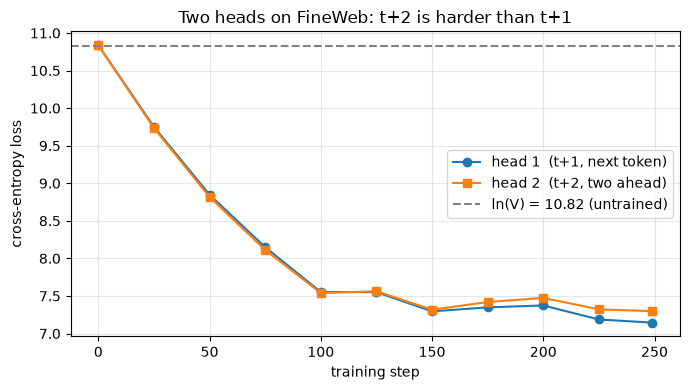

In [13]:
plt.figure(figsize=(7,4))
plt.plot(hist["step"], hist["l1"], "o-", label="head 1  (t+1, next token)")
plt.plot(hist["step"], hist["l2"], "s-", label="head 2  (t+2, two ahead)")
plt.axhline(math.log(VOCAB), ls="--", c="gray", label=f"ln(V) = {math.log(VOCAB):.2f} (untrained)")
plt.xlabel("training step"); plt.ylabel("cross-entropy loss")
plt.title("Two heads on FineWeb: t+2 is harder than t+1")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**What we see.** Both heads leave `ln(V)` together. `loss2` (t+2) tracks at or above `loss1` (t+1)
and the gap grows with training: the next-token head keeps capturing easy local dependencies
(finishing a word, closing punctuation) that carry no equivalent signal two tokens out, so head 2's
loss floor is higher and it descends more slowly. The two heads share one backbone, so this is a
clean comparison of *task difficulty*, not of model capacity.

---
# Part 3 — the off-by-one trap (the demonstration)

The warning made real. We deliberately shift the targets the **wrong** way — predict token `t-1`
instead of `t+1` (`logits[:, 1:]` against `tokens[:, :-1]`). Watch the loss fall to a beautiful curve
anyway: the model just learns the identity-ish copy of the token it can already see. **No exception is
raised.** Only decoding the strings exposes it — the "predictions" reproduce the *input*, not the
*next* token.

In [14]:
bad = GPT(Config(VOCAB)).to(device)
opt = torch.optim.AdamW(bad.parameters(), lr=3e-4)
data = fineweb_tokens.to(device)

print("Training with a WRONG (backwards) shift:")
for step in range(150):
    x = get_batch()
    logits = bad(x)
    # WRONG: predict the PREVIOUS token instead of the next one
    loss = F.cross_entropy(logits[:, 1:].reshape(-1, VOCAB), x[:, :-1].reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 30 == 0 or step == 149:
        print(f"  step {step:3d} | loss {loss.item():.3f}   <- looks like it is 'learning'!")

# Now PRINT THE STRINGS to expose it
ids = enc.encode(fineweb_docs[0])[:12]
seq = torch.tensor([ids], device=device)
with torch.no_grad():
    pred = bad(seq).argmax(-1)[0]     # model's argmax at each position
print(f"\n{'pos':>3}  {'INPUT (token i)':<16} {'model predicts':<16} {'CORRECT next (i+1)'}")
print("-" * 60)
for i in range(len(ids) - 1):
    print(f"{i:>3}  {repr(enc.decode([ids[i]])):<16} "
          f"{repr(enc.decode([pred[i].item()])):<16} {repr(enc.decode([ids[i+1]]))}")
print("\nThe 'predictions' echo the INPUT token, not the next one. The pretty loss curve was a lie.")
print("This is why Part 1.2 prints strings: it is the only check that catches a reversed shift.")

Training with a WRONG (backwards) shift:
  step   0 | loss 10.851   <- looks like it is 'learning'!
  step  30 | loss 9.549   <- looks like it is 'learning'!
  step  60 | loss 8.383   <- looks like it is 'learning'!
  step  90 | loss 7.810   <- looks like it is 'learning'!
  step 120 | loss 7.452   <- looks like it is 'learning'!
  step 149 | loss 7.164   <- looks like it is 'learning'!

pos  INPUT (token i)  model predicts   CORRECT next (i+1)
------------------------------------------------------------
  0  '|'              ' the'           'View'
  1  'View'           '.'              'ing'
  2  'ing'            ')'              ' Single'
  3  ' Single'        '\n'             ' Post'
  4  ' Post'          '.'              ' From'
  5  ' From'          '\n'             ':'
  6  ':'              ' in'            ' Sp'
  7  ' Sp'            '.'              'oil'
  8  'oil'            '\n'             'ers'
  9  'ers'            '\n'             ' for'
 10  ' for'           ' in'     

---
# Write-up

## Part 1 — the seven numbers (from this run; re-run to refresh)

| # | Quantity | Value |
|---|----------|-------|
| 1 | **Shapes** | tokens `(B,T)` → hidden `(B,T,C=128)` → logits `(B,T,V=50257)`; flattened to `(B*(T-1), V)` vs `(B*(T-1),)` |
| 2 | **String-verified shift** | `input i → target i+1` reads forward; reconstructed target text matches the source |
| 3 | **Padding mask** | contributing tokens drop from *all* to *real-only*; masked loss differs from raw |
| 4 | **Doc-packing boundary** | loss before vs after masking the cross-document prediction (last-of-A → first-of-B) |
| 5 | **Untrained perplexity** | ≈ **50,257** (≈ vocab), loss ≈ `ln(V)` ≈ **10.82** — init bug fix verified |
| 6 | **Tied vs untied params** | difference = `vocab*n_embd` = **6,432,896** (tied 7.23M vs untied 13.67M) |
| 7 | **Chunked-CE peak memory** | ordinary vs chunked peak MB, with ratio = N/chunk (observed **4.00×** lower at B·T=1024, chunk=256) |

## Part 2 — the two losses

- `loss1` (t+1) and `loss2` (t+2) both start at ≈ `ln(V)` ≈ 10.82.
- Their **sum** is the training objective.
- Over training, `loss2` stays **≥** `loss1` and the **gap widens** — predicting two tokens ahead is
  strictly harder, so the two-ahead head has a higher loss floor and descends more slowly.

## Part 3 — the demonstration

A reversed target shift produced a smooth, falling loss curve **and raised no error**. Printing the
strings exposed it immediately: the model's argmax reproduced the *input* token rather than the *next*
one. Conclusion — **always print the strings.** A good-looking scalar is not evidence of a correct
harness; the few lines between model output and loss are where the bugs live.
